<a href="https://colab.research.google.com/github/Lamia12344/ahmedali/blob/main/train_vgg19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
zip_file_path = "/content/drive/MyDrive/data2/dataset iris.zip"

In [ ]:
!unzip "/content/drive/MyDrive/data2/dataset iris.zip" -d "/content/drive/MyDrive/data2"

Streaming output truncated to the last 5000 lines.
   creating: /content/drive/MyDrive/data2/dataset iris/test/P351_right/
  inflating: /content/drive/MyDrive/data2/dataset iris/test/P351_right/S5351R00.jpg  
  inflating: /content/drive/MyDrive/data2/dataset iris/test/P351_right/S5351R01.jpg  
  inflating: /content/drive/MyDrive/data2/dataset iris/test/P351_right/S5351R04.jpg  
  inflating: /content/drive/MyDrive/data2/dataset iris/test/P351_right/S5351R08.jpg  
   creating: /content/drive/MyDrive/data2/dataset iris/test/P352_left/
  inflating: /content/drive/MyDrive/data2/dataset iris/test/P352_left/S5352L00.jpg  
  inflating: /content/drive/MyDrive/data2/dataset iris/test/P352_left/S5352L01.jpg  
  inflating: /content/drive/MyDrive/data2/dataset iris/test/P352_left/S5352L04.jpg  
  inflating: /content/drive/MyDrive/data2/dataset iris/test/P352_left/S5352L08.jpg  
   creating: /content/drive/MyDrive/data2/dataset iris/test/P352_right/
  inflating: /content/drive/MyDrive/data2/dataset 

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
from tensorflow.keras.preprocessing.image import load_img

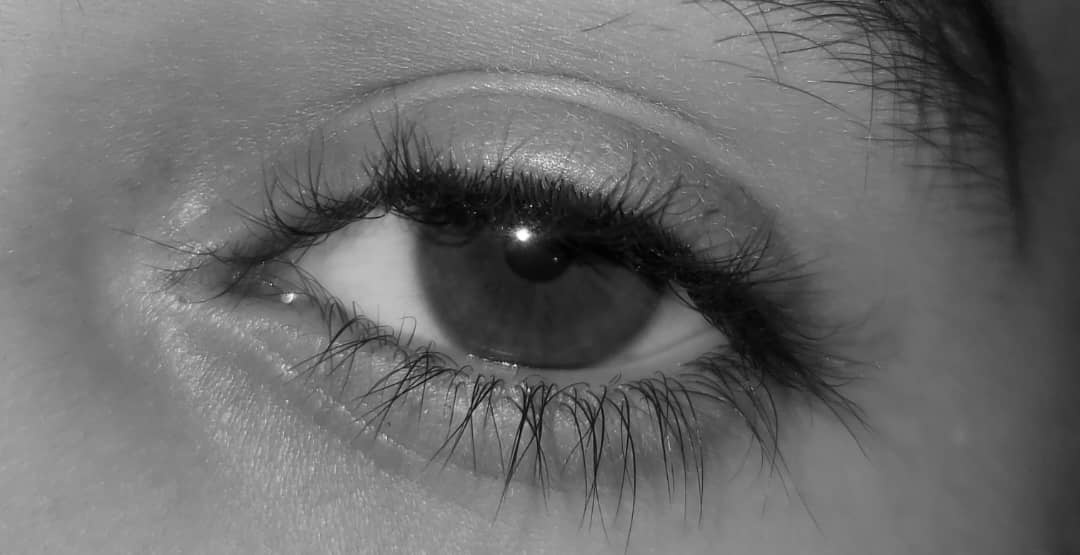

In [ ]:
path = r'/content/drive/MyDrive/data2/dataset iris/train/mohamed_left/'
name = 'WhatsApp Image 2024-12-23 at 10.28.23 PM.jpeg'
fullname = path + '/' + name
load_img(fullname)

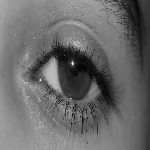

In [ ]:
load_img(fullname, target_size=(150, 150))

In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.applications.vgg19 import decode_predictions

In [ ]:
model = VGG19(
    weights='imagenet',
    input_shape=(224, 224, 3)
)

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


In [ ]:
img = load_img(fullname, target_size=(224, 224))
x = np.array(img)
x.shape

(224, 224, 3)

In [ ]:
X = np.array([x])
X.shape

(1, 224, 224, 3)

In [ ]:
X = preprocess_input(X)

In [ ]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [ ]:
pred.shape

(1, 1000)

In [ ]:
pred[0, :10]

array([8.73498539e-06, 2.28039535e-05, 1.12365326e-03, 2.59030401e-03,
       1.32571615e-04, 4.71267704e-05, 5.34336956e-04, 1.43991683e-05,
       1.50279975e-05, 1.41001074e-04], dtype=float32)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
image_size = (224, 224)
batch_size = 32

In [ ]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    r"/content/drive/MyDrive/data2/dataset iris/train",
    seed=1,
    target_size=image_size,
    batch_size=batch_size,
)

Found 3012 images belonging to 502 classes.


In [ ]:
dc=train_ds.class_indices

In [ ]:
dc

{'P250_left': 0,
 'P250_right': 1,
 'P251_left': 2,
 'P251_right': 3,
 'P252_left': 4,
 'P252_right': 5,
 'P253_left': 6,
 'P253_right': 7,
 'P254_left': 8,
 'P254_right': 9,
 'P255_left': 10,
 'P255_right': 11,
 'P256_left': 12,
 'P256_right': 13,
 'P257_left': 14,
 'P257_right': 15,
 'P258_left': 16,
 'P258_right': 17,
 'P259_left': 18,
 'P259_right': 19,
 'P260_left': 20,
 'P260_right': 21,
 'P261_left': 22,
 'P261_right': 23,
 'P262_left': 24,
 'P262_right': 25,
 'P263_left': 26,
 'P263_right': 27,
 'P264_left': 28,
 'P264_right': 29,
 'P265_left': 30,
 'P265_right': 31,
 'P266_left': 32,
 'P266_right': 33,
 'P267_left': 34,
 'P267_right': 35,
 'P268_left': 36,
 'P268_right': 37,
 'P269_left': 38,
 'P269_right': 39,
 'P270_left': 40,
 'P270_right': 41,
 'P271_left': 42,
 'P271_right': 43,
 'P272_left': 44,
 'P272_right': 45,
 'P273_left': 46,
 'P273_right': 47,
 'P274_left': 48,
 'P274_right': 49,
 'P275_left': 50,
 'P275_right': 51,
 'P276_left': 52,
 'P276_right': 53,
 'P277_left

In [ ]:
array1=np.array(list(dc.values()))
import pandas as pd
import numpy as np
array1 = np.array(list(dc.values()))
df = pd.DataFrame({'Name': list(dc.keys()), 'Class': array1})
df.to_csv('output.csv', index=False)
print("تم حفظ الملف بنجاح!")

تم حفظ الملف بنجاح!


In [ ]:
validation_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = validation_gen.flow_from_directory(
    r"/content/drive/MyDrive/data2/dataset iris/test",
    seed=1,
    target_size=image_size,
    batch_size=batch_size,
)

Found 2008 images belonging to 502 classes.


In [ ]:
base_model = VGG19(
    weights='imagenet',
    input_shape=(224, 224, 3),
    include_top=False
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=(224, 224, 3))

base = base_model(inputs, training=False)
vector = keras.layers.GlobalAveragePooling2D()(base)
inner=keras.layers.Dense(1024,activation='relu')(vector)
outputs = keras.layers.Dense(502)(inner)

model = keras.Model(inputs, outputs)

In [ ]:
model

<Functional name=functional_1, built=True>

In [ ]:
learning_rate = 0.001

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate),
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "VGG19_v1_{epoch:02d}_{val_accuracy:.3f}.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode='max'
    )
]

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds,callbacks=callbacks)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


95/95 ━━━━━━━━━━━━━━━━━━━━ 66s 534ms/step - accuracy: 0.0240 - loss: 7.2076 - val_accuracy: 0.1434 - val_loss: 5.1199
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 53s 369ms/step - accuracy: 0.2965 - loss: 3.8717 - val_accuracy: 0.4502 - val_loss: 2.7875
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 370ms/step - accuracy: 0.7498 - loss: 1.3046 - val_accuracy: 0.6220 - val_loss: 1.8128
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 388ms/step - accuracy: 0.8990 - loss: 0.5521 - val_accuracy: 0.7435 - val_loss: 1.2191
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 443ms/step - accuracy: 0.9640 - loss: 0.2553 - val_accuracy: 0.8048 - val_loss: 1.0052
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 77s 383ms/step - accuracy: 0.9899 - loss: 0.1131 - val_accuracy: 0.8247 - val_loss: 0.8518
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 371ms/step - accuracy: 0.9940 - loss: 0.0694 - val_accuracy: 0.8541 - val_loss: 0.7310
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 391ms/step - accuracy: 0.9975 - loss: 0.0388 - val_accuracy: 0.864

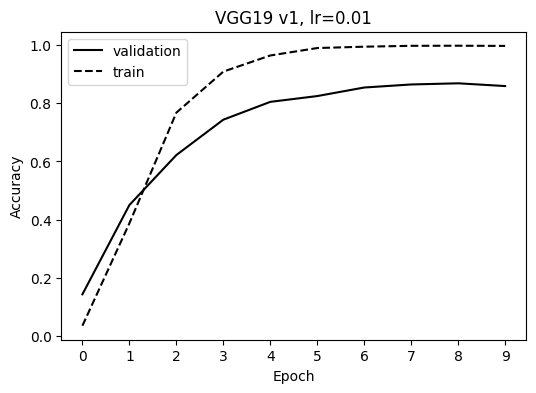

In [ ]:
plt.figure(figsize=(6, 4))

epochs = history.epoch
val = history.history['val_accuracy']
train = history.history['accuracy']

plt.plot(epochs, val, color='black', linestyle='solid', label='validation')
plt.plot(epochs, train, color='black', linestyle='dashed', label='train')

plt.title('VGG19 v1, lr=0.01')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.xticks(np.arange(10))

plt.legend()


plt.savefig('{VGG19}.svg')

plt.show()

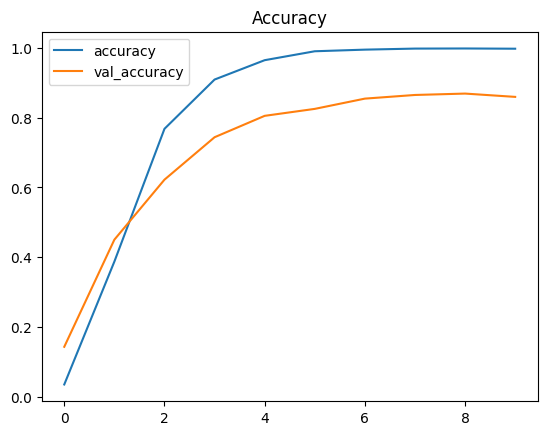

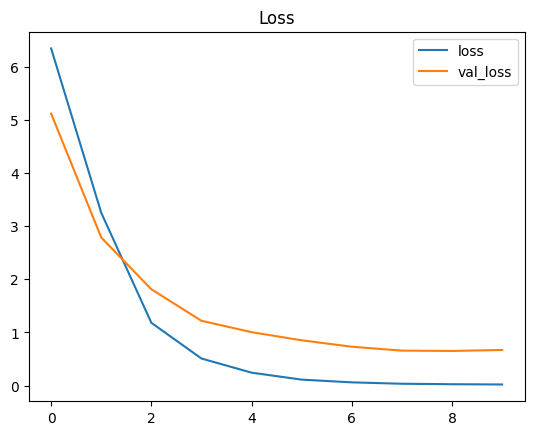

In [ ]:
losses = pd.DataFrame(model.history.history)
losses[['accuracy', 'val_accuracy']].plot(title="Accuracy")
plt.show()
losses[['loss', 'val_loss']].plot(title="Loss")
plt.show()

In [ ]:
print("\nEvaluating the model:")
evaluation = model.evaluate(train_ds)
print(f"Test Loss: {evaluation[0]}\nTest Accuracy: {evaluation[1]}")



Evaluating the model:
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 235ms/step - accuracy: 0.9985 - loss: 0.0130
Test Loss: 0.015580322593450546
Test Accuracy: 0.9973439574241638


In [ ]:
# Add this line at the beginning of your code, or with other imports
from sklearn.metrics import confusion_matrix, classification_report

# Assuming val_ds is your validation/test dataset
# Extract the true labels from the validation dataset
test_classes = val_ds.classes

# Assuming you have a list of class labels that correspond to the classes
# in your dataset, replace the example labels below with your actual labels:
class_labels = list(val_ds.class_indices.keys())


y_pred = np.argmax(model.predict(val_ds), axis=-1)  # Predict on validation data (val_ds)
cm = confusion_matrix(test_classes, y_pred)

print("\nClassification Report:")
print(classification_report(test_classes, y_pred, target_names=class_labels))

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step

Classification Report:
               precision    recall  f1-score   support

    P250_left       0.00      0.00      0.00         4
   P250_right       0.00      0.00      0.00         4
    P251_left       0.00      0.00      0.00         4
   P251_right       0.00      0.00      0.00         4
    P252_left       0.00      0.00      0.00         4
   P252_right       0.00      0.00      0.00         4
    P253_left       0.00      0.00      0.00         4
   P253_right       0.00      0.00      0.00         4
    P254_left       0.00      0.00      0.00         4
   P254_right       0.00      0.00      0.00         4
    P255_left       0.00      0.00      0.00         4
   P255_right       0.00      0.00      0.00         4
    P256_left       0.00      0.00      0.00         4
   P256_right       0.00      0.00      0.00         4
    P257_left       0.00      0.00      0.00         4
   P257_right       0.00      0.00      0.00         

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model.save('iris_recognition_VGG19m_model.h5')

In [ ]:
ls /content/drive/MyDrive!

ls: cannot access '/content/drive/MyDrive!': No such file or directory


In [ ]:
from google.colab import files
files.download('/content/iris_recognition_VGG19m_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image
import numpy as np
from skimage import transform
def load(filename):
   np_image = Image.open(filename)
   np_image = np.array(np_image).astype('float32')/255
   np_image = transform.resize(np_image, (256, 256,3))
   np_image = np.expand_dims(np_image, axis=0)
   return np_image

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
model = load_model(r'/content/iris_recognition_VGG19m_model.h5')